In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [37]:
df = pd.read_csv(r"C:\Users\kkrit\OneDrive\Documents\ML\archive (20)\Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [38]:
print(df.isnull().sum())
df = df.dropna()
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [39]:
X = df[['Annual_Income', 'Spending_Score']]
# X = df[['Age', 'Annual_Income', 'Spending_Score']]

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

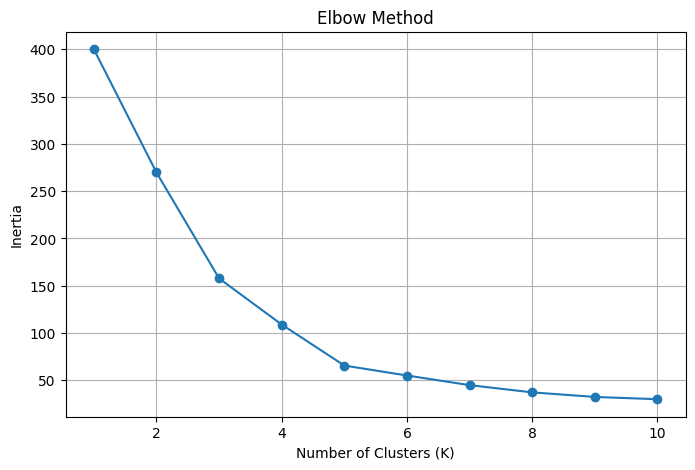

In [41]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

In [42]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [43]:
print("Inertia:", kmeans.inertia_)
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


In [44]:
silhouette_scores = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3213
K = 3, Silhouette Score = 0.4666
K = 4, Silhouette Score = 0.4939
K = 5, Silhouette Score = 0.5547
K = 6, Silhouette Score = 0.5399
K = 7, Silhouette Score = 0.5281
K = 8, Silhouette Score = 0.4552
K = 9, Silhouette Score = 0.4571
K = 10, Silhouette Score = 0.4432


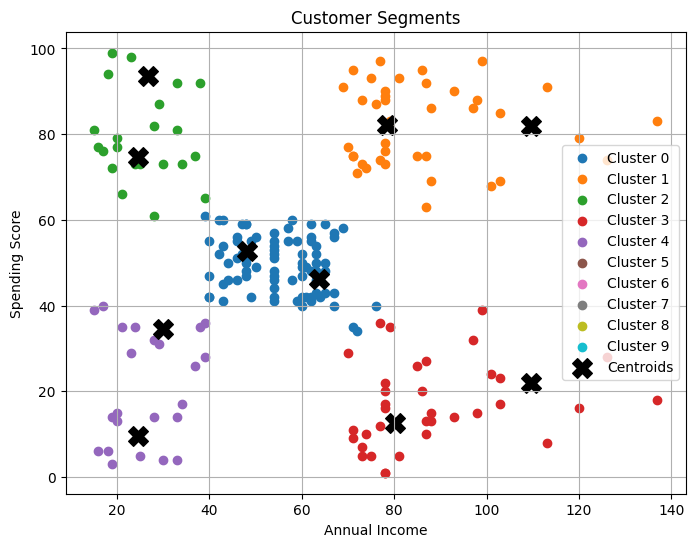

In [45]:
plt.figure(figsize=(8,6))

for i in range(k):
    plt.scatter(X.iloc[clusters == i, 0],
                X.iloc[clusters == i, 1],
                label=f'Cluster {i}')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.legend()
plt.grid()
plt.show()

In [46]:
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
print(cluster_summary)

               Age  Annual_Income  Spending_Score
Cluster                                          
0        42.716049      55.296296       49.518519
1        32.692308      86.538462       82.128205
2        25.272727      25.727273       79.363636
3        41.114286      88.200000       17.114286
4        45.217391      26.304348       20.913043
